In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve,auc, precision_recall_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score
from sklearn.model_selection import train_test_split
import xgboost as xgb

In [2]:
# Paths
data_dir = '/Users/zamiulalam/Documents/Informatics_Project/mimic_processed_data/mimic3-benchmarks/data/in-hospital-mortality/train'
label_file = '/Users/zamiulalam/Documents/Informatics_Project/mimic_processed_data/mimic3-benchmarks/data/in-hospital-mortality/train/listfile.csv'

# Load label file
labels = pd.read_csv(label_file)

# Make a dict: {episode_episode: y_true}
label_dict = dict(zip(labels['stay'], labels['y_true']))

all_dfs = []

# Loop over all episode CSV files
for fname in os.listdir(data_dir):
    if fname.endswith("_timeseries.csv"):
        fpath = os.path.join(data_dir, fname)

        df0 = pd.read_csv(fpath)

        # Add episode name
        df0['episode'] = fname

        # Add y_true from listfile
        df0['y_true'] = label_dict.get(fname)

        all_dfs.append(df0)

# Combine into one DataFrame
df = pd.concat(all_dfs, ignore_index=True)

df.head()

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Height,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true
0,0.006389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,75188_episode2_timeseries.csv,0
1,0.023056,NaN,54.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,100.0,12.0,92.0,NaN,NaN,NaN,75188_episode2_timeseries.csv,0
2,0.056389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,152.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75188_episode2_timeseries.csv,0
3,0.139722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75188_episode2_timeseries.csv,0
4,0.323056,NaN,52.0,NaN,NaN,NaN,NaN,NaN,174.0,NaN,NaN,62.0,99.0,NaN,92.0,NaN,NaN,7.4,75188_episode2_timeseries.csv,0


In [3]:
df.sample(10)

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Height,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true
317212,17.383333,NaN,58.0,NaN,NaN,NaN,NaN,NaN,NaN,91.0,NaN,74.000000,99.0,16.0,105.0,NaN,NaN,NaN,32484_episode1_timeseries.csv,0
1194084,8.524722,NaN,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.000000,NaN,NaN,120.0,NaN,NaN,NaN,31024_episode1_timeseries.csv,0
1138079,11.910556,NaN,76.0,NaN,4 Spontaneously,6 Obeys Commands,15.0,5 Oriented,NaN,114.0,NaN,98.333298,90.0,33.0,143.0,37.055599,NaN,NaN,4816_episode4_timeseries.csv,1
1233781,8.393611,NaN,55.0,NaN,NaN,NaN,NaN,NaN,NaN,121.0,NaN,71.000000,100.0,10.0,96.0,NaN,NaN,NaN,96260_episode3_timeseries.csv,0
197428,7.094444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67924_episode2_timeseries.csv,1
743472,5.817778,NaN,97.0,NaN,NaN,NaN,NaN,NaN,NaN,82.0,NaN,140.667007,94.0,27.0,228.0,NaN,NaN,NaN,23290_episode1_timeseries.csv,0
441963,23.481944,NaN,55.0,NaN,NaN,NaN,NaN,NaN,NaN,83.0,NaN,74.666702,100.0,13.0,114.0,NaN,NaN,NaN,20836_episode1_timeseries.csv,0
197608,21.530278,NaN,50.0,NaN,NaN,NaN,NaN,NaN,124.0,67.0,NaN,64.000000,91.0,25.0,103.0,NaN,NaN,NaN,65056_episode1_timeseries.csv,0
1392437,27.354722,NaN,68.0,0.35,NaN,No response,NaN,No Response-ETT,NaN,74.0,NaN,95.000000,100.0,16.0,136.0,NaN,NaN,NaN,5171_episode2_timeseries.csv,1
1382231,24.596111,NaN,62.0,NaN,NaN,NaN,NaN,NaN,NaN,76.0,NaN,71.333298,98.0,20.0,90.0,NaN,NaN,NaN,26719_episode1_timeseries.csv,0


In [4]:
#Find the number of missing values in each column
missing_values = df.isnull().sum()

#Turn the missing value counts into percentages
missing_values_percentage = (missing_values / len(df)) * 100

#Return counts and percentages of missing values in each column
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})

missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
Capillary refill rate,1455000,99.791090
Height,1454657,99.767566
Weight,1427176,97.882783
Fraction inspired oxygen,1376659,94.418077
pH,1335179,91.573174
Glascow coma scale total,1299168,89.103362
Glucose,1210442,83.018094
Glascow coma scale eye opening,1205498,82.679010
Glascow coma scale motor response,1189425,81.576644
Glascow coma scale verbal response,1189172,81.559292


In [5]:
len(df['episode'].unique())

17903

In [6]:
len(labels)

17903

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458046 entries, 0 to 1458045
Data columns (total 20 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   Hours                               1458046 non-null  float64
 1   Capillary refill rate               3046 non-null     float64
 2   Diastolic blood pressure            1013819 non-null  float64
 3   Fraction inspired oxygen            81387 non-null    float64
 4   Glascow coma scale eye opening      252548 non-null   object 
 5   Glascow coma scale motor response   268621 non-null   object 
 6   Glascow coma scale total            158878 non-null   float64
 7   Glascow coma scale verbal response  268874 non-null   object 
 8   Glucose                             247604 non-null   float64
 9   Heart Rate                          1055961 non-null  float64
 10  Height                              3389 non-null     float64
 11  Mean blood 

In [29]:
# Create mapping from episode → index string
file_map = {name: str(i) for i, name in enumerate(df['episode'].unique())}

# Replace values
df['episode'] = df['episode'].map(file_map)

In [30]:
df.head(50)

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,Height,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true
0,0.006389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,0,0
1,0.023056,NaN,54.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,100.0,12.0,92.0,NaN,NaN,NaN,0,0
2,0.056389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,152.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,0.139722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,0.323056,NaN,52.0,NaN,NaN,NaN,NaN,NaN,174.0,NaN,NaN,62.0,99.0,NaN,92.0,NaN,NaN,7.40,0,0
5,0.373056,NaN,53.0,NaN,To Speech,Obeys Commands,NaN,No Response-ETT,NaN,84.0,NaN,68.0,100.0,18.0,91.0,35.388889,NaN,NaN,0,0
6,0.589722,NaN,52.0,NaN,NaN,NaN,NaN,NaN,NaN,83.0,NaN,67.0,100.0,15.0,89.0,NaN,NaN,NaN,0,0
7,0.623056,NaN,51.0,NaN,NaN,NaN,NaN,NaN,NaN,83.0,NaN,66.0,100.0,15.0,89.0,NaN,NaN,NaN,0,0
8,0.873056,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,83.0,NaN,77.0,100.0,13.0,105.0,NaN,NaN,NaN,0,0
9,1.373056,NaN,67.0,0.4,To Speech,Obeys Commands,NaN,No Response-ETT,NaN,82.0,NaN,90.0,100.0,14.0,127.0,NaN,NaN,NaN,0,0


In [18]:
temp = df['Temperature'].unique()

<Axes: >

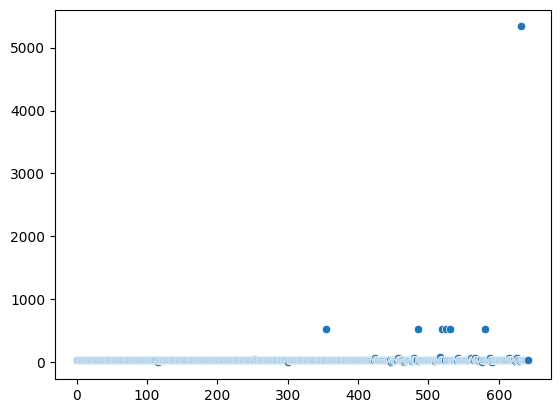

In [31]:
sns.scatterplot(temp)

In [51]:
temp1 = temp[temp < 110]

<Axes: >

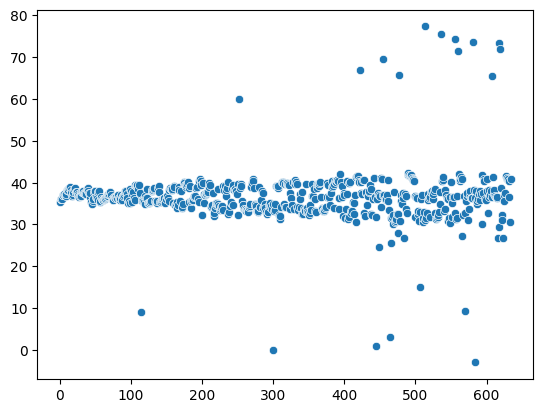

In [52]:
sns.scatterplot(temp1)

In [32]:
df.columns

Index(['Hours', 'Capillary refill rate', 'Diastolic blood pressure',
       'Fraction inspired oxygen', 'Glascow coma scale eye opening',
       'Glascow coma scale motor response', 'Glascow coma scale total',
       'Glascow coma scale verbal response', 'Glucose', 'Heart Rate', 'Height',
       'Mean blood pressure', 'Oxygen saturation', 'Respiratory rate',
       'Systolic blood pressure', 'Temperature', 'Weight', 'pH', 'episode',
       'y_true'],
      dtype='object')

In [53]:
episodes_to_remove = df.loc[df['Temperature'] > 110, 'episode'].unique()
df = df[~df['episode'].isin(episodes_to_remove)]

In [54]:
print(episodes_to_remove)

[]


<Axes: >

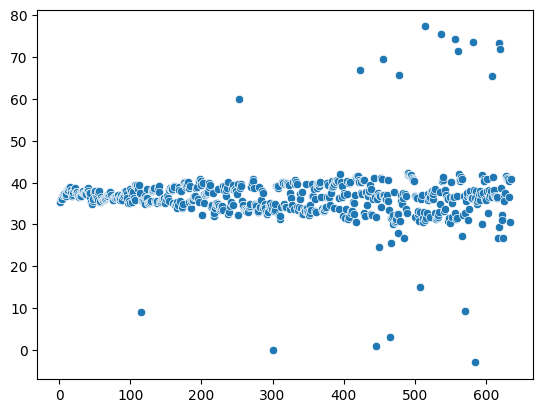

In [55]:
temp = df['Temperature'].unique()
sns.scatterplot(temp)

In [38]:
low_temp = df.loc[df['Temperature'] < 20, 'episode'].unique()
print(low_temp)

['26' '725' '889' '1366' '1379' '1791' '3243' '3616' '4487' '4537' '4831'
 '5030' '5605' '5679' '5825' '5986' '6001' '6037' '6085' '6145' '6440'
 '7155' '7518' '7635' '7674' '7702' '7739' '7829' '8193' '8338' '8602'
 '8868' '9247' '9664' '9810' '10386' '10508' '10995' '11241' '11521'
 '11968' '12016' '12558' '13068' '13252' '13297' '13660' '14870' '14979'
 '15091' '15514' '15582' '15597' '16064' '16815' '17186' '17499' '17578'
 '17743']


In [42]:
print(
    df.loc[df['episode'].isin(low_temp)]
      .groupby('episode')['y_true']
      .first()
)

episode
10386    0
10508    1
10995    0
11241    1
11521    0
11968    0
12016    0
12558    0
13068    0
13252    1
13297    0
1366     0
13660    0
1379     0
14870    0
14979    0
15091    0
15514    1
15582    0
15597    0
16064    0
16815    0
17186    0
17499    0
17578    1
17743    1
1791     0
26       0
3243     1
3616     0
4487     1
4537     0
4831     0
5030     0
5605     0
5679     0
5825     0
5986     1
6001     0
6037     0
6085     0
6145     0
6440     0
7155     0
725      0
7518     0
7635     1
7674     0
7702     0
7739     0
7829     0
8193     0
8338     0
8602     0
8868     0
889      0
9247     0
9664     0
9810     0
Name: y_true, dtype: int64


In [69]:
mask = df['Temperature'] >= 60
df.loc[mask, 'Temperature'] = (df.loc[mask, 'Temperature'] - 32.0) * 5.0 / 9.0
print(mask)

0          False
1          False
2          False
3          False
4          False
           ...  
1458041    False
1458042    False
1458043    False
1458044    False
1458045    False
Name: Temperature, Length: 1454650, dtype: bool


In [70]:
for i,v in enumerate(mask):
    if v == True:
        print(i)


27092
318485
442746
523220
587662
656520
758984
848661
870924
1010572
1213307
1293028
1293029
1302226


In [71]:
epiz = df.loc[df['Temperature'] >= 60.0, 'episode'].unique()
print(epiz)

[]


In [72]:
print(temp)

[        nan 35.38888889 36.         36.05555556 36.16666667 36.94444444
 37.16666667 37.27777778 37.         36.88888889 37.33333333 38.16666667
 38.38888889 38.22222222 38.74444444 38.88888889 38.33333333 37.61111111
 36.77777778 37.05555556 37.72222222 38.5        38.72222222 37.88888889
 37.44444444 37.66666667 37.38888889 36.83333333 36.61111111 36.72222222
 37.66669846 36.88890076 37.77780151 37.83333249 37.94444614 37.61110942
 37.55559921 37.22222222 37.33333164 38.55555556 38.66666667 37.94444444
 37.5        36.66666667 37.55555556 35.33333333 34.83333333 35.55555556
 36.11111111 37.83333333 38.05555556 38.         36.55555556 36.44444444
 35.83333333 37.77777778 38.11111111 35.5        35.72222222 36.5
 36.0000017  35.90000153 35.80000136 36.10000186 36.20000203 36.29999924
 36.59999847 36.70000076 36.79999924 37.20000076 37.40000153 37.70000076
 37.80000051 37.16669846 36.16669846 35.77780151 35.88890076 36.66669846
 36.61111196 36.38890076 36.55559921 36.33333418 37.055599

<Axes: >

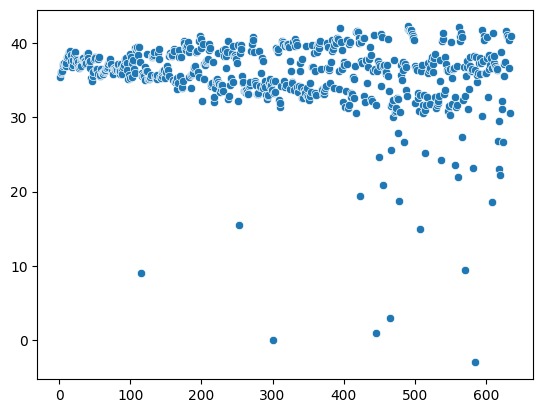

In [73]:
temp = df['Temperature'].unique()
sns.scatterplot(temp)

In [75]:
df['Glascow coma scale motor response'].value_counts()

Glascow coma scale motor response
6 Obeys Commands      111095
Obeys Commands         76664
5 Localizes Pain       22297
Localizes Pain         14109
1 No Response          12341
4 Flex-withdraws       12204
Flex-withdraws          8158
No response             7567
3 Abnorm flexion        1209
2 Abnorm extensn        1083
Abnormal extension       960
Abnormal Flexion         855
Name: count, dtype: int64

In [76]:
gcs_motor_map = {
    # 6
    '6 Obeys Commands': 6,
    'Obeys Commands': 6,

    # 5
    '5 Localizes Pain': 5,
    'Localizes Pain': 5,

    # 4
    '4 Flex-withdraws': 4,
    'Flex-withdraws': 4,

    # 3
    '3 Abnorm flexion': 3,
    'Abnormal Flexion': 3,

    # 2
    '2 Abnorm extensn': 2,
    'Abnormal extension': 2,

    # 1
    '1 No Response': 1,
    'No response': 1
}

df['Glascow coma scale motor response'] = (
    df['Glascow coma scale motor response']
    .replace(gcs_motor_map)
)

/var/folders/rz/xn1t5mlj5wv1k082mq_q2hdr0000gn/T/ipykernel_5962/874301714.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(gcs_motor_map)


In [77]:
df['Glascow coma scale motor response'].value_counts()

Glascow coma scale motor response
6.0    187759
5.0     36406
4.0     20362
1.0     19908
3.0      2064
2.0      2043
Name: count, dtype: int64

In [78]:
df['Glascow coma scale eye opening'].value_counts()

Glascow coma scale eye opening
4 Spontaneously    93154
Spontaneously      60911
3 To speech        30072
1 No Response      27328
To Speech          23621
2 To pain          10427
To Pain             6973
Name: count, dtype: int64

In [79]:
gcs_eye_map = {
    # 4
    '4 Spontaneously': 4,
    'Spontaneously': 4,

    # 3
    '3 To speech': 3,
    'To Speech': 3,

    # 2
    '2 To pain': 2,
    'To Pain': 2,

    # 1
    '1 No Response': 1
}

df['Glascow coma scale eye opening'] = (
    df['Glascow coma scale eye opening']
    .replace(gcs_eye_map)
)

/var/folders/rz/xn1t5mlj5wv1k082mq_q2hdr0000gn/T/ipykernel_5962/2787305659.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(gcs_eye_map)


In [80]:
df['Glascow coma scale eye opening'].value_counts()

Glascow coma scale eye opening
4.0    154065
3.0     53693
1.0     27328
2.0     17400
Name: count, dtype: int64

In [81]:
df['Glascow coma scale verbal response'].value_counts()

Glascow coma scale verbal response
5 Oriented                 74486
1.0 ET/Trach               64716
Oriented                   50902
No Response-ETT            38884
4 Confused                 13376
Confused                   10899
No Response                 4099
1 No Response               3465
2 Incomp sounds             3157
Incomprehensible sounds     2620
3 Inapprop words            1233
Inappropriate Words          953
Name: count, dtype: int64

In [82]:
gcs_verbal_map = {
    # Score 5
    'Oriented': 5,
    '5 Oriented': 5,

    # Score 4
    'Confused': 4,
    '4 Confused': 4,

    # Score 3
    'Inappropriate Words': 3,
    '3 Inapprop words': 3,

    # Score 2
    'Incomprehensible sounds': 2,
    '2 Incomp sounds': 2,

    # Score 1
    'No Response': 1,
    '1 No Response': 1,
    'No Response-ETT': 1,
    '1.0 ET/Trach': 1
}

df['Glascow coma scale verbal response'] = (
    df['Glascow coma scale verbal response']
    .replace(gcs_verbal_map)
)

/var/folders/rz/xn1t5mlj5wv1k082mq_q2hdr0000gn/T/ipykernel_5962/2842855645.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(gcs_verbal_map)


In [83]:
df['Glascow coma scale verbal response'].value_counts()

Glascow coma scale verbal response
5.0    125388
1.0    111164
4.0     24275
2.0      5777
3.0      2186
Name: count, dtype: int64

In [84]:
df['Glascow total'] = df['Glascow coma scale verbal response']+df['Glascow coma scale eye opening']+df['Glascow coma scale motor response']

In [85]:
df['Glascow total'].value_counts()

Glascow total
15.0    114403
10.0     25670
14.0     24498
11.0     16293
8.0      12206
9.0      11985
3.0      11056
7.0      10226
13.0      8541
6.0       7866
12.0      3523
4.0       1925
5.0       1804
Name: count, dtype: int64

In [86]:
df['Glascow coma scale total'].value_counts()

Glascow coma scale total
15.0    69345
10.0    15405
14.0    12248
3.0     10976
11.0    10524
7.0      8263
8.0      7997
6.0      7479
9.0      7173
13.0     4746
12.0     1897
4.0      1424
5.0      1401
Name: count, dtype: int64

In [87]:
#Find the number of missing values in each column
missing_values = df.isnull().sum()

#Turn the missing value counts into percentages
missing_values_percentage = (missing_values / len(df)) * 100

#Return counts and percentages of missing values in each column
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})

missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
Capillary refill rate,1451604,99.790603
Height,1451265,99.767298
Weight,1423802,97.879352
Fraction inspired oxygen,1373321,94.409033
pH,1331837,91.557213
Glascow coma scale total,1295772,89.077923
Glucose,1207154,82.985873
Glascow total,1204654,82.814010
Glascow coma scale eye opening,1202164,82.642835
Glascow coma scale motor response,1186108,81.539064


In [88]:
lala = df[df['Capillary refill rate'].notna()]

In [89]:
lala.tail()

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,...,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true,Glascow total
1456578,23.791944,0.0,45.0,NaN,4.0,6.0,15.0,5.0,NaN,81.0,...,65.0,95.0,11.0,103.0,36.500000,NaN,NaN,17883,0,15.0
1456583,25.791944,0.0,43.0,NaN,NaN,NaN,NaN,NaN,NaN,83.0,...,68.0,35.0,14.0,107.0,36.599998,NaN,NaN,17883,0,NaN
1456606,39.791944,0.0,53.0,NaN,4.0,6.0,15.0,5.0,NaN,94.0,...,78.0,96.0,15.0,129.0,37.000000,NaN,NaN,17883,0,15.0
1456612,44.291944,0.0,44.0,NaN,4.0,6.0,15.0,5.0,NaN,91.0,...,67.0,96.0,14.0,103.0,37.099999,NaN,NaN,17883,0,15.0
1456617,47.791944,0.0,50.0,NaN,4.0,6.0,15.0,5.0,NaN,85.0,...,74.0,95.0,18.0,114.0,37.200001,NaN,NaN,17883,0,15.0


In [90]:
lalaz = lala[lala['y_true'] == 1]

In [91]:
lalaz.head(20)

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,...,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true,Glascow total
36173,2.586389,1.0,98.0,NaN,2.0,2.0,5.0,1.0,NaN,103.0,...,121.000000,NaN,6.0,136.0,35.111109,74.599998,NaN,465,1,5.0
87373,44.404167,0.0,69.0,NaN,1.0,1.0,3.0,1.0,NaN,144.0,...,82.000000,98.0,38.0,96.0,38.444443,NaN,NaN,1088,1,3.0
109443,4.723889,0.0,67.0,NaN,4.0,6.0,15.0,5.0,NaN,102.0,...,87.666702,98.0,22.0,129.0,36.388901,91.000000,NaN,1337,1,15.0
109447,7.723889,0.0,81.0,NaN,4.0,6.0,15.0,5.0,NaN,102.0,...,95.666702,97.0,21.0,125.0,NaN,NaN,NaN,1337,1,15.0
109450,10.723889,0.0,70.0,NaN,3.0,6.0,13.0,4.0,NaN,96.0,...,94.666702,96.0,21.0,144.0,NaN,NaN,NaN,1337,1,13.0
109454,14.723889,0.0,77.0,NaN,4.0,6.0,14.0,4.0,NaN,107.0,...,100.333000,99.0,26.0,147.0,NaN,NaN,NaN,1337,1,14.0
109458,17.723889,0.0,NaN,NaN,4.0,6.0,14.0,4.0,NaN,106.0,...,NaN,95.0,25.0,NaN,NaN,NaN,NaN,1337,1,14.0
109464,22.723889,0.0,73.0,NaN,4.0,6.0,15.0,5.0,NaN,101.0,...,88.333298,97.0,20.0,119.0,NaN,NaN,NaN,1337,1,15.0
109472,28.723889,0.0,77.0,NaN,4.0,6.0,15.0,5.0,NaN,99.0,...,90.333298,96.0,26.0,117.0,36.833335,NaN,NaN,1337,1,15.0
109482,36.723889,0.0,76.0,NaN,1.0,1.0,3.0,1.0,210.0,109.0,...,96.000000,96.0,12.0,130.0,36.388901,NaN,NaN,1337,1,3.0


In [92]:
print(df.columns)

Index(['Hours', 'Capillary refill rate', 'Diastolic blood pressure',
       'Fraction inspired oxygen', 'Glascow coma scale eye opening',
       'Glascow coma scale motor response', 'Glascow coma scale total',
       'Glascow coma scale verbal response', 'Glucose', 'Heart Rate', 'Height',
       'Mean blood pressure', 'Oxygen saturation', 'Respiratory rate',
       'Systolic blood pressure', 'Temperature', 'Weight', 'pH', 'episode',
       'y_true', 'Glascow total'],
      dtype='object')


In [93]:
df.columns

Index(['Hours', 'Capillary refill rate', 'Diastolic blood pressure',
       'Fraction inspired oxygen', 'Glascow coma scale eye opening',
       'Glascow coma scale motor response', 'Glascow coma scale total',
       'Glascow coma scale verbal response', 'Glucose', 'Heart Rate', 'Height',
       'Mean blood pressure', 'Oxygen saturation', 'Respiratory rate',
       'Systolic blood pressure', 'Temperature', 'Weight', 'pH', 'episode',
       'y_true', 'Glascow total'],
      dtype='object')

In [94]:
df.tail()

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,...,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true,Glascow total
1458041,44.3825,NaN,68.0,NaN,NaN,NaN,NaN,NaN,NaN,78.0,...,87.000000,98.0,16.0,138.0,NaN,NaN,NaN,17902,0,NaN
1458042,44.7825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17902,0,NaN
1458043,45.3825,NaN,83.0,NaN,2.0,5.0,8.0,1.0,NaN,78.0,...,86.333298,99.0,16.0,171.0,NaN,NaN,NaN,17902,0,8.0
1458044,46.3825,NaN,85.0,NaN,NaN,NaN,NaN,NaN,NaN,81.0,...,95.000000,98.0,16.0,142.0,37.666698,NaN,NaN,17902,0,NaN
1458045,47.3825,NaN,72.0,NaN,1.0,5.0,7.0,1.0,NaN,73.0,...,92.333298,98.0,16.0,141.0,NaN,NaN,NaN,17902,0,7.0


In [95]:


df_ep = df.groupby('episode')

In [96]:
df_ep1 = df[df['episode']== '0']

In [97]:
df_ep465 = df[df['episode']== '465']

In [98]:
df_ep465.head(50)

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,...,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true,Glascow total
36171,0.653056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,99.0,NaN,NaN,NaN,NaN,7.22,465,1,NaN
36172,1.286389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,99.0,NaN,NaN,NaN,NaN,7.27,465,1,NaN
36173,2.586389,1.0,98.0,NaN,2.0,2.0,5.0,1.0,NaN,103.0,...,121.0,NaN,6.0,136.0,35.111109,74.599998,NaN,465,1,5.0
36174,2.753056,NaN,97.0,NaN,NaN,NaN,NaN,NaN,NaN,97.0,...,106.0,NaN,26.0,133.0,NaN,NaN,NaN,465,1,NaN
36175,2.919722,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,93.0,...,83.0,100.0,29.0,101.0,NaN,NaN,NaN,465,1,NaN
36176,3.086389,NaN,69.0,NaN,NaN,NaN,NaN,NaN,312.0,89.0,...,69.0,NaN,22.0,86.0,NaN,NaN,NaN,465,1,NaN
36177,3.253056,NaN,72.0,NaN,NaN,NaN,NaN,NaN,NaN,93.0,...,85.0,NaN,23.0,92.0,NaN,NaN,NaN,465,1,NaN
36178,3.286389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,39.0,NaN,NaN,NaN,NaN,NaN,465,1,NaN
36179,3.586389,NaN,NaN,NaN,2.0,2.0,5.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,465,1,5.0
36180,3.619722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,99.0,NaN,NaN,NaN,NaN,7.35,465,1,NaN


In [99]:
df_ep465.columns

Index(['Hours', 'Capillary refill rate', 'Diastolic blood pressure',
       'Fraction inspired oxygen', 'Glascow coma scale eye opening',
       'Glascow coma scale motor response', 'Glascow coma scale total',
       'Glascow coma scale verbal response', 'Glucose', 'Heart Rate', 'Height',
       'Mean blood pressure', 'Oxygen saturation', 'Respiratory rate',
       'Systolic blood pressure', 'Temperature', 'Weight', 'pH', 'episode',
       'y_true', 'Glascow total'],
      dtype='object')

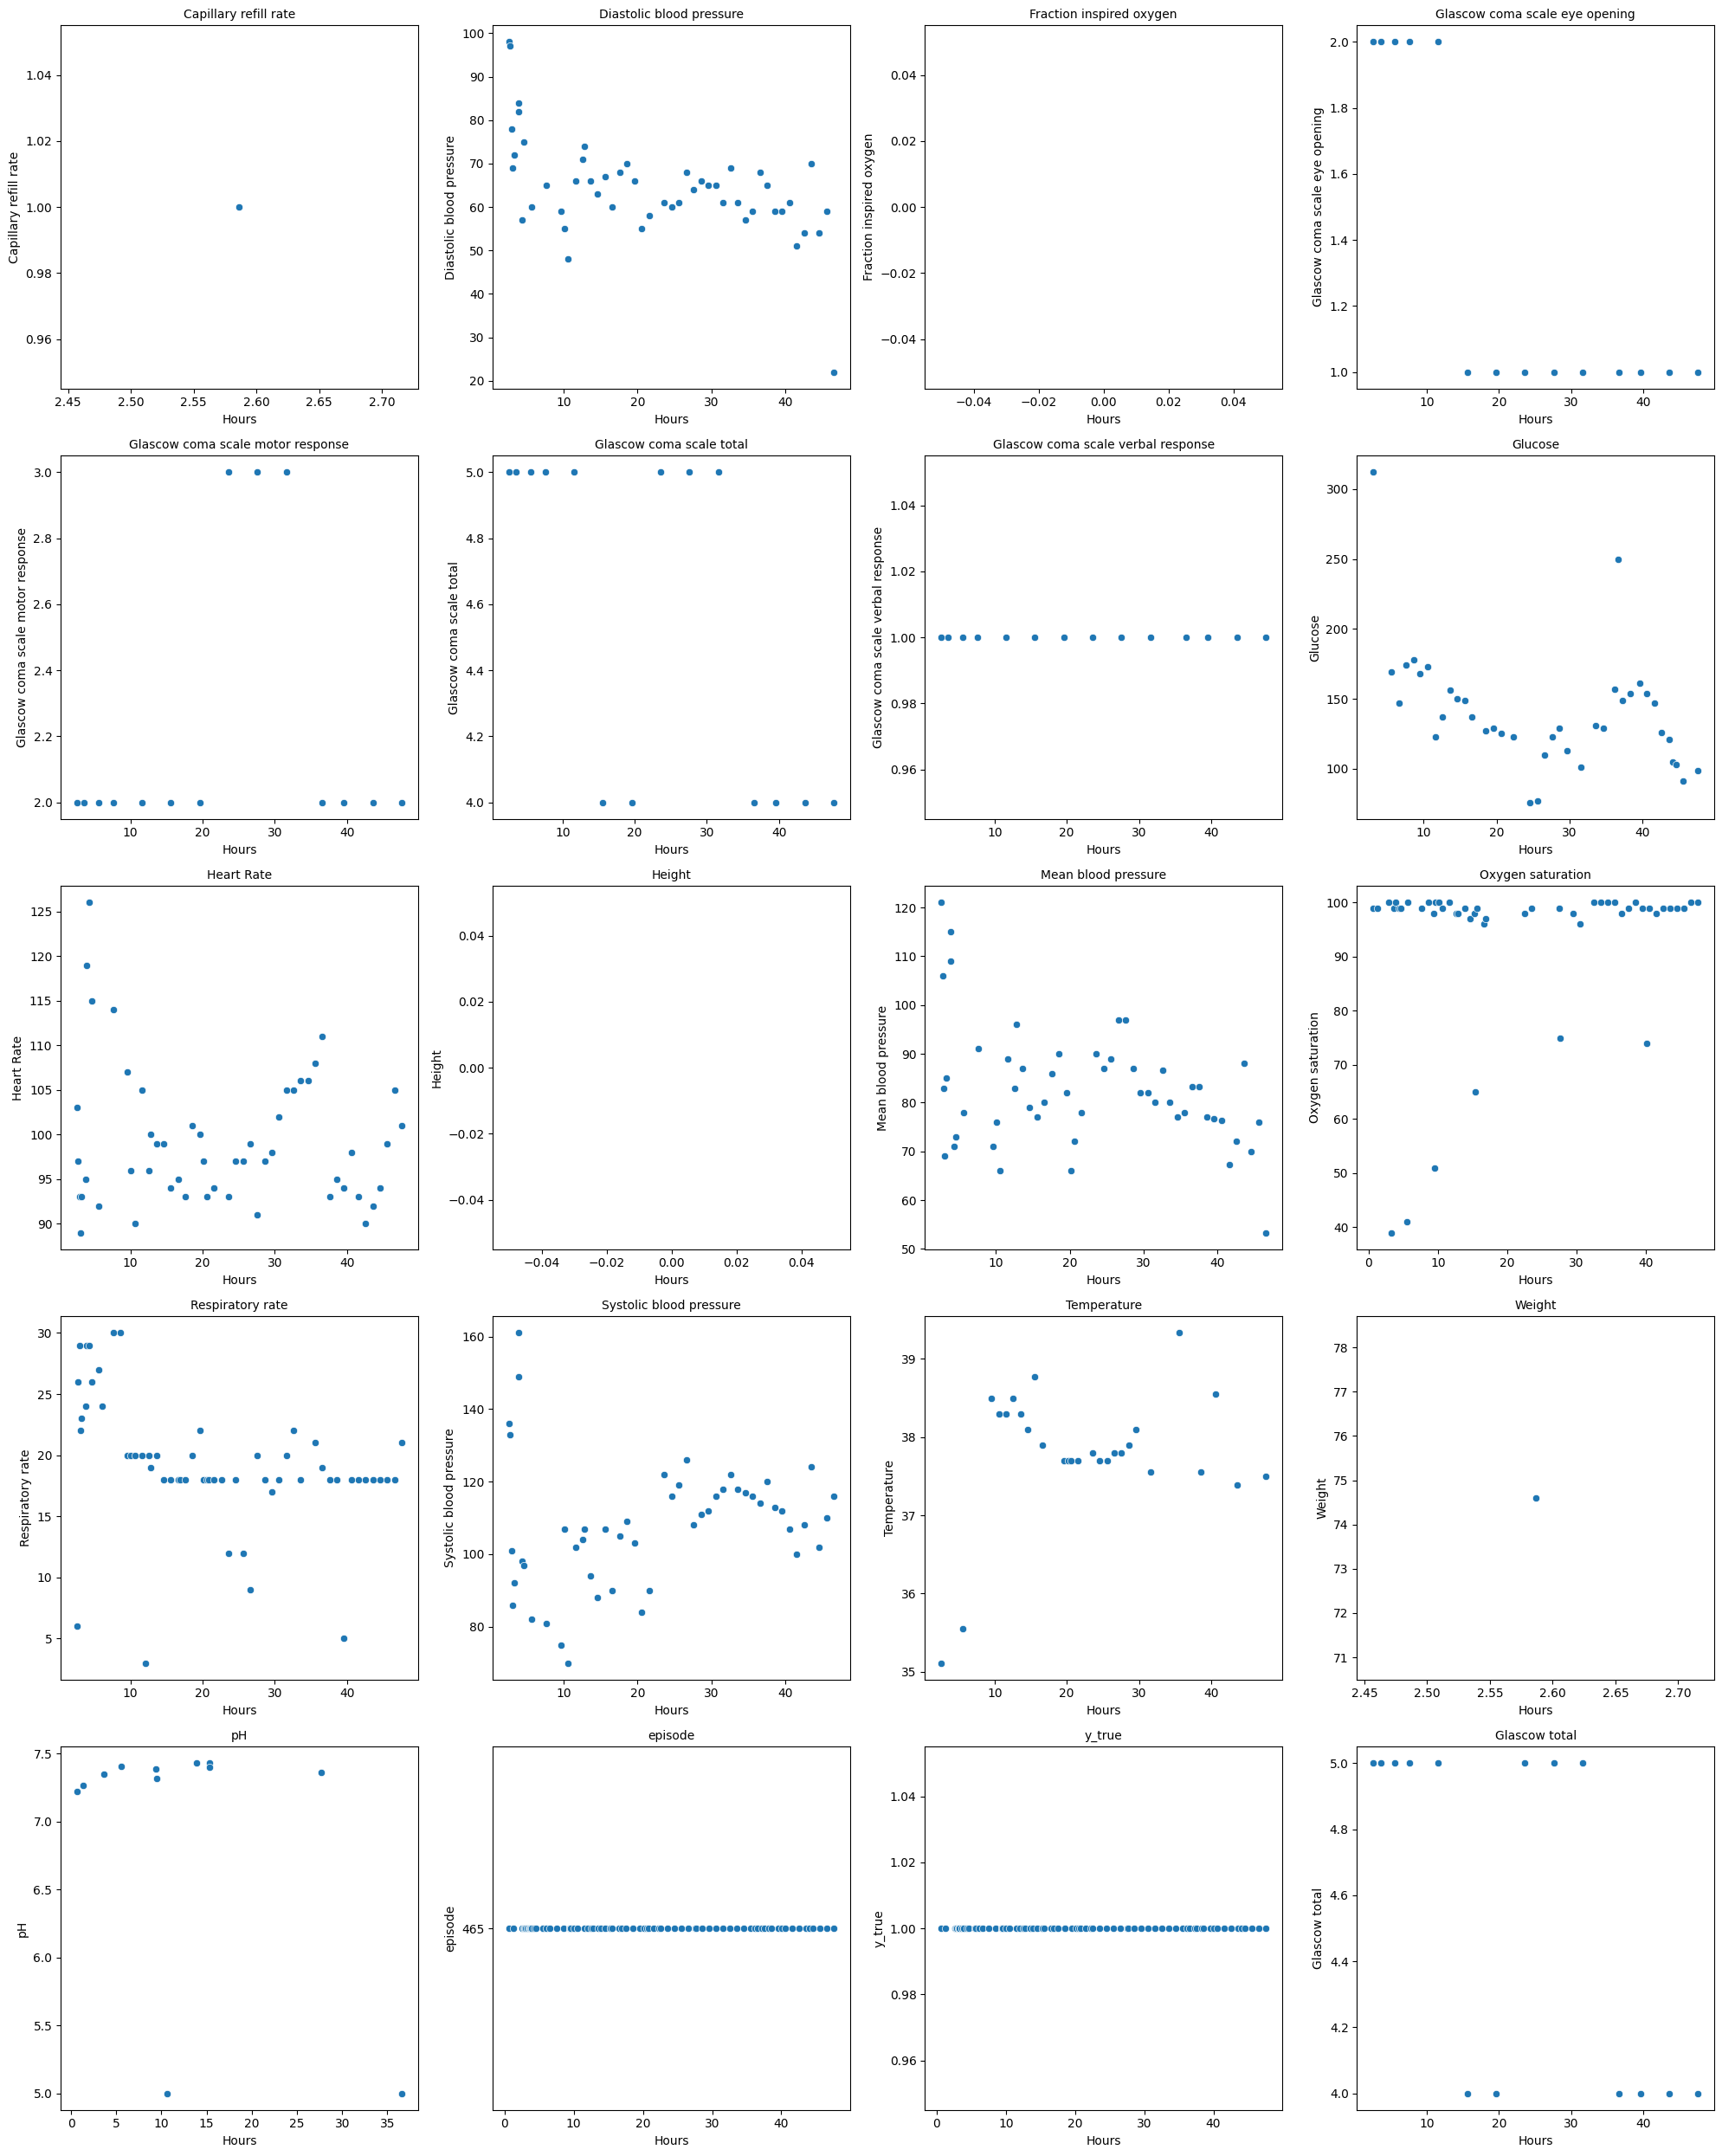

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

y_columns = [
    'Capillary refill rate', 'Diastolic blood pressure',
    'Fraction inspired oxygen', 'Glascow coma scale eye opening',
    'Glascow coma scale motor response', 'Glascow coma scale total',
    'Glascow coma scale verbal response', 'Glucose', 'Heart Rate', 'Height',
    'Mean blood pressure', 'Oxygen saturation', 'Respiratory rate',
    'Systolic blood pressure', 'Temperature', 'Weight', 'pH', 'episode',
    'y_true', 'Glascow total'
]

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(y_columns):
    sns.scatterplot(data=df_ep465, x='Hours', y=col, ax=axes[i]) #, alpha=0.5, s=10)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Hours')
    axes[i].set_ylabel(col)

#i = 0

# Hide any unused subplots
for j in range(len(y_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [101]:
df_ep465_impute = df_ep465.apply(lambda x: x.bfill().ffill())

In [102]:
df_ep465_impute

,Hours,Capillary refill rate,Diastolic blood pressure,Fraction inspired oxygen,Glascow coma scale eye opening,Glascow coma scale motor response,Glascow coma scale total,Glascow coma scale verbal response,Glucose,Heart Rate,...,Mean blood pressure,Oxygen saturation,Respiratory rate,Systolic blood pressure,Temperature,Weight,pH,episode,y_true,Glascow total
36171,0.653056,1.0,98.0,NaN,2.0,2.0,5.0,1.0,312.0,103.0,...,121.000000,99.0,6.0,136.0,35.111109,74.599998,7.22,465,1,5.0
36172,1.286389,1.0,98.0,NaN,2.0,2.0,5.0,1.0,312.0,103.0,...,121.000000,99.0,6.0,136.0,35.111109,74.599998,7.27,465,1,5.0
36173,2.586389,1.0,98.0,NaN,2.0,2.0,5.0,1.0,312.0,103.0,...,121.000000,100.0,6.0,136.0,35.111109,74.599998,7.35,465,1,5.0
36174,2.753056,1.0,97.0,NaN,2.0,2.0,5.0,1.0,312.0,97.0,...,106.000000,100.0,26.0,133.0,35.555599,74.599998,7.35,465,1,5.0
36175,2.919722,1.0,78.0,NaN,2.0,2.0,5.0,1.0,312.0,93.0,...,83.000000,100.0,29.0,101.0,35.555599,74.599998,7.35,465,1,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36245,44.086389,1.0,54.0,NaN,1.0,2.0,4.0,1.0,105.0,94.0,...,70.000000,99.0,18.0,102.0,37.500000,74.599998,5.00,465,1,4.0
36246,44.586389,1.0,54.0,NaN,1.0,2.0,4.0,1.0,103.0,94.0,...,70.000000,99.0,18.0,102.0,37.500000,74.599998,5.00,465,1,4.0
36247,45.586389,1.0,59.0,NaN,1.0,2.0,4.0,1.0,91.0,99.0,...,76.000000,99.0,18.0,110.0,37.500000,74.599998,5.00,465,1,4.0
36248,46.586389,1.0,22.0,NaN,1.0,2.0,4.0,1.0,99.0,105.0,...,53.333302,100.0,18.0,116.0,37.500000,74.599998,5.00,465,1,4.0


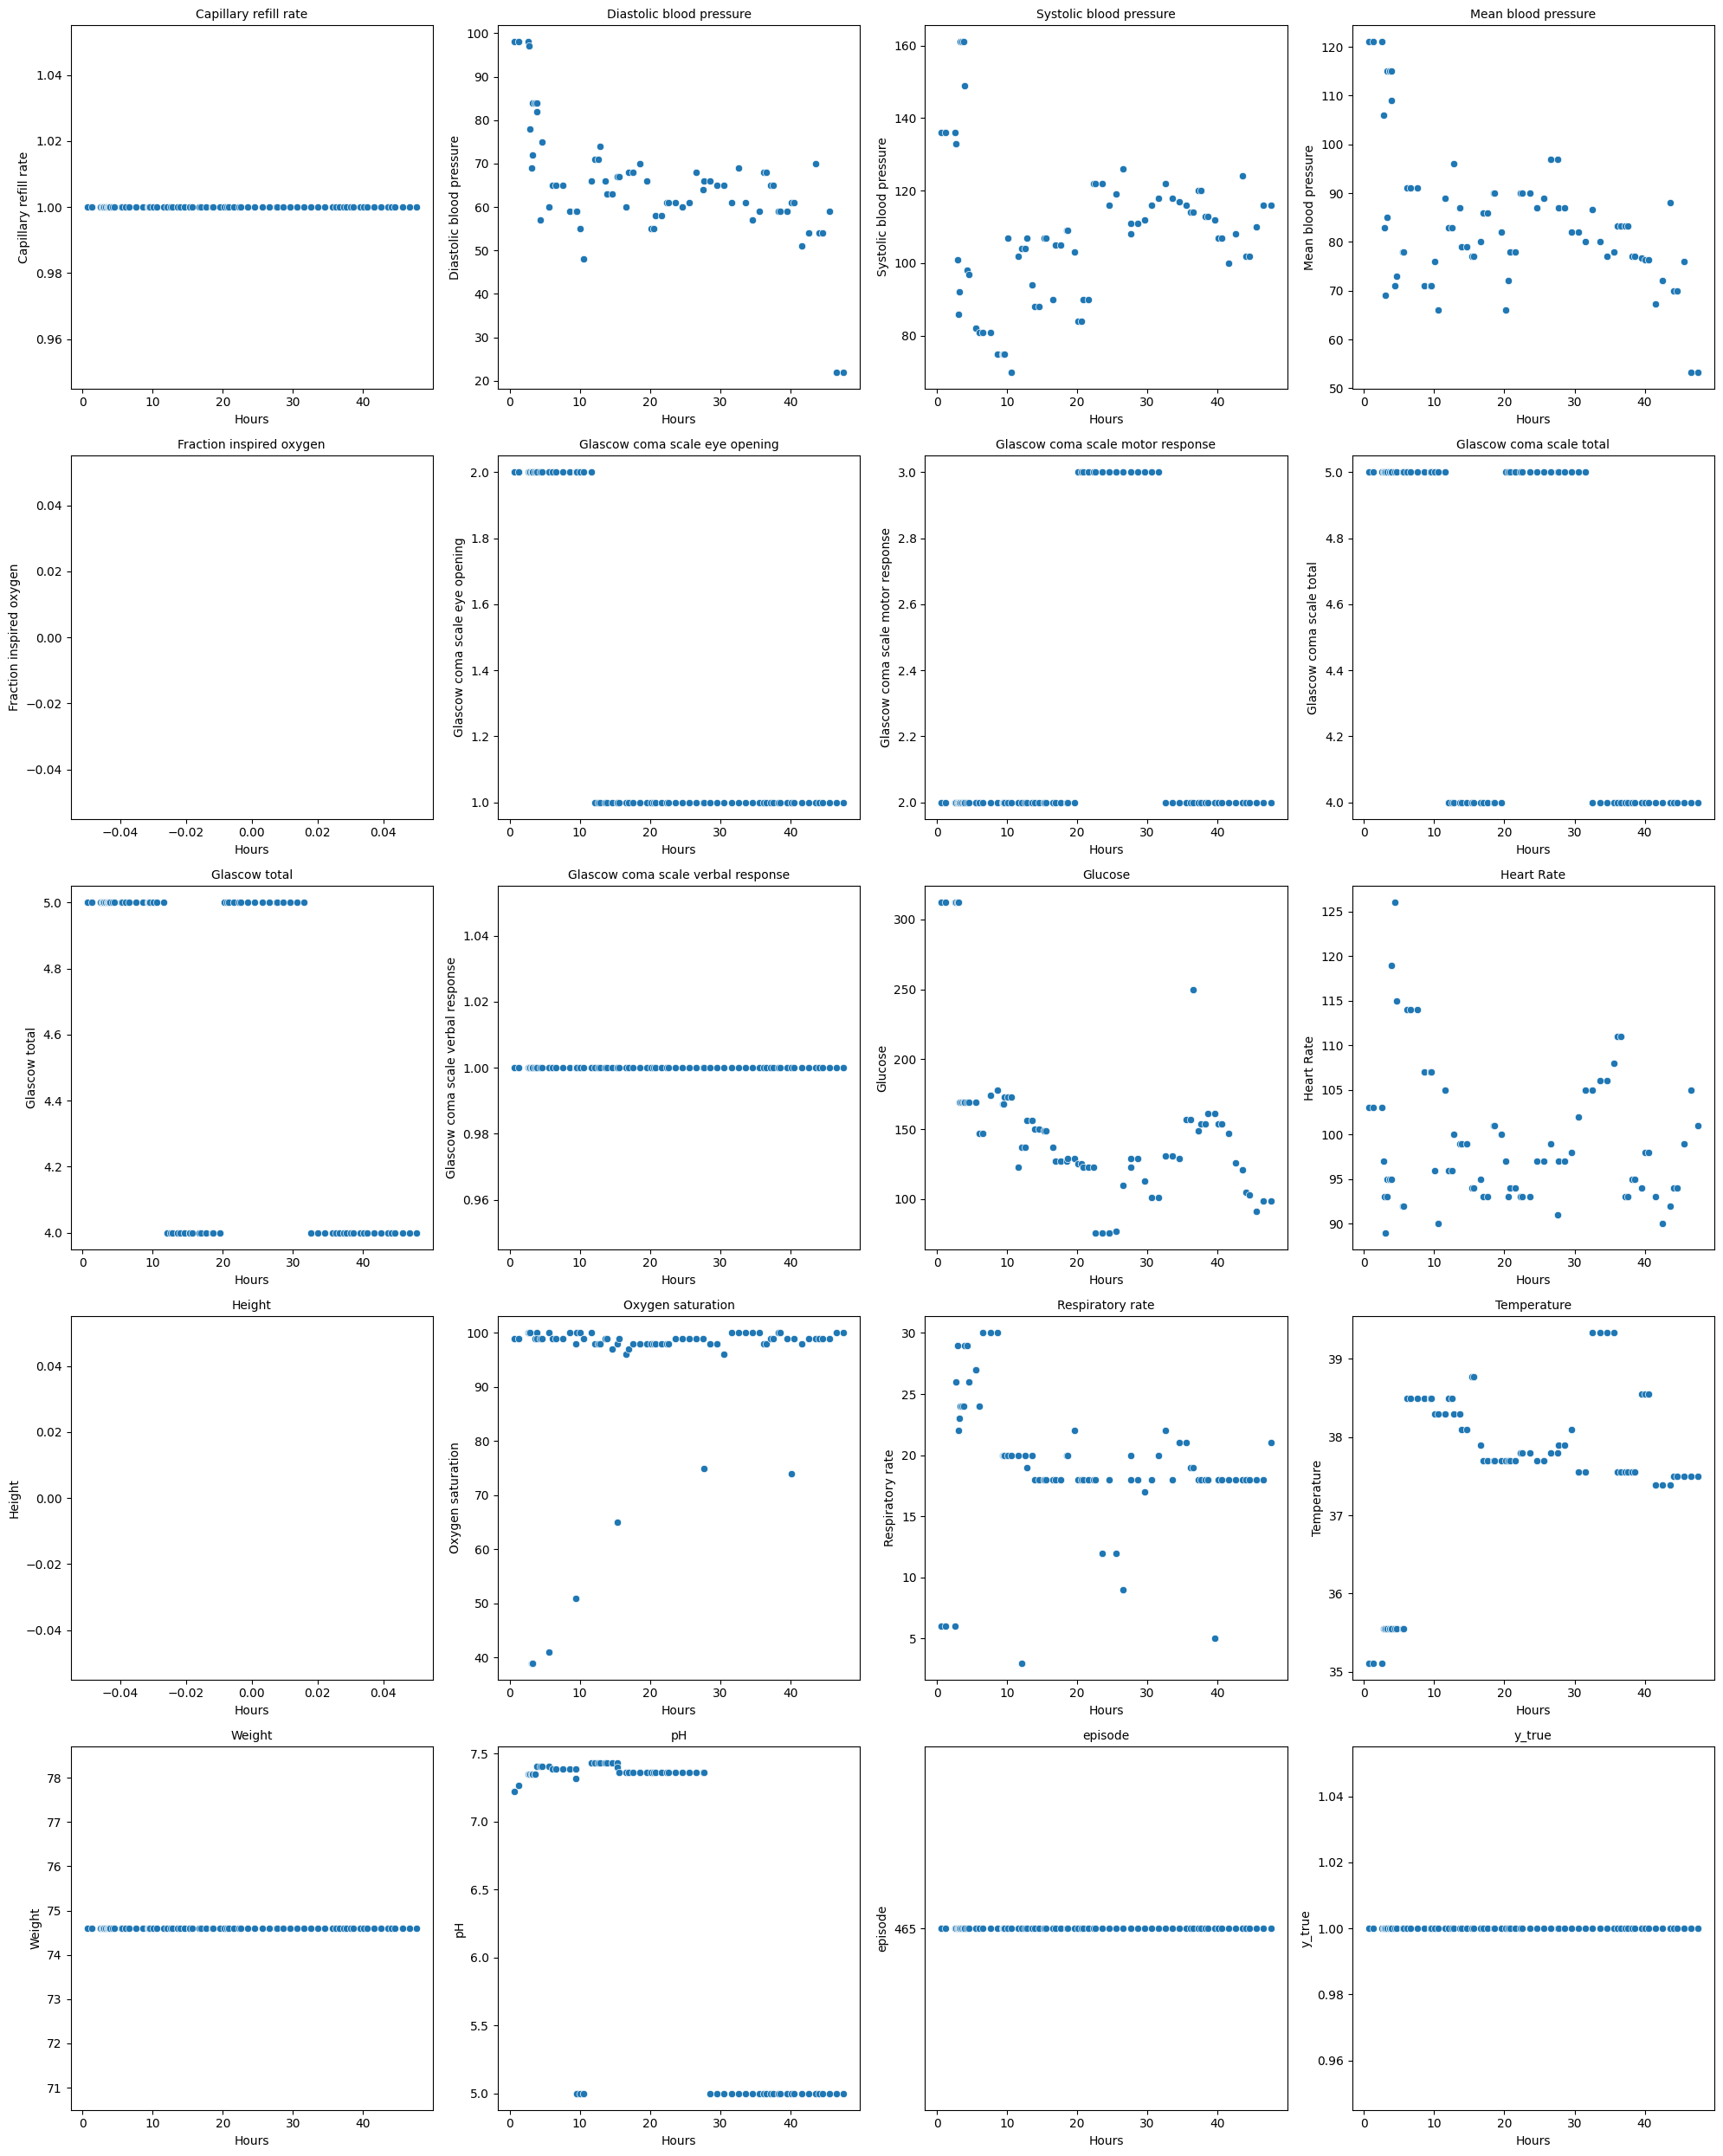

In [103]:
y_columns = [
    'Capillary refill rate', 'Diastolic blood pressure', 'Systolic blood pressure', 'Mean blood pressure',
    'Fraction inspired oxygen', 'Glascow coma scale eye opening',
    'Glascow coma scale motor response', 'Glascow coma scale total', 'Glascow total',
    'Glascow coma scale verbal response', 'Glucose', 'Heart Rate', 'Height',
    'Oxygen saturation', 'Respiratory rate',
    'Temperature', 'Weight', 'pH', 'episode',
    'y_true'
]

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(y_columns):
    sns.scatterplot(data=df_ep465_impute, x='Hours', y=col, ax=axes[i]) #, alpha=0.5, s=10)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Hours')
    axes[i].set_ylabel(col)

#i = 0

# Hide any unused subplots
for j in range(len(y_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()